In [53]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Standardization request for input survey

- Year(s) of Major Renovation(s): comma-separated numerics only. 
- Seismic Upgrade Year: Should restrict to significant upgrades to the lateral force-resisting systems. comma-separated numerics only. 
- Floors Below Grade: is grade-fixity good enough for fixed? Should we model basement as floor 1?
- Primary dimension of the building (length) in main directions
- Higher priority on story heights
- Length of just LFRS (m)


### Really cool long term ideas

- Allow some Bayesian mix of engineer-reviewed properties (capacities, periods, e.g.) and have that alter Hazus values
- Allow engineer-override on properties

### Handle Excel

A better output would be to ask the user to manually use Excel to export the first sheet to CSV.

In [77]:
'''
import os 
import pandas as pd
from pathlib import Path

file_path = os.getcwd()
proj_root = os.path.dirname(file_path)

refm_excel_path = Path(file_path) / 'refm.xlsx'
output_csv = 'refm.csv'

# convert first sheet of the excel
df = pd.read_excel(refm_excel_path, sheet_name=0)

df.to_csv(output_csv, index=False)
'''

"\nimport os \nimport pandas as pd\nfrom pathlib import Path\n\nfile_path = os.getcwd()\nproj_root = os.path.dirname(file_path)\n\nrefm_excel_path = Path(file_path) / 'refm.xlsx'\noutput_csv = 'refm.csv'\n\n# convert first sheet of the excel\ndf = pd.read_excel(refm_excel_path, sheet_name=0)\n\ndf.to_csv(output_csv, index=False)\n"

In [78]:
import mimlos.mimlos.inventory as inv
import mimlos
import os 
import pandas as pd
from pathlib import Path

In [79]:
file_path = os.getcwd()
raw_csv = Path(file_path) / 'refm.csv'
inventory = inv.Inventory.load_from_csv(raw_csv)

In [80]:
df_raw = inventory.df_raw
print(df_raw['Seismic Force Resisting System in the East-West Direction'].unique())
print(df_raw['Seismic Force Resisting System in the North-South Direction'].unique())
print(df_raw['Site Class'].unique())

['CIW' nan 'CSW' 'RMC' 'WLF' 'WLF-P9' 'URM' 'SBF' 'PCW']
['CIW' nan 'CSW' 'RMC' 'WLF' 'WLF-P9' 'URM' 'PCW' 'WPB']
['C' nan 'E' 'D']


In [81]:
print(df_raw['Floors Above Grade'].unique())

[ 5.  4.  1.  2. 12.  6.  0.  3.  7.  8. 14.  9. nan 41. 10. 13. 15. 11.
 34.]


In [82]:
inventory.inventory_df

,ID,Facility/Asset,Address,Review Phase,Approver,Screener,Drawings,Desktop Review Date,Site Visit,Site Review Date,...,FEMA P154 RVS Level 2 Screening S-Score,SEG Level 2 - SQST S-Score,Building: Collapse Likelihood,Building: Post Disaster Importance,Building: Occupancy,Building: Seismic Screening Data,Building: Seismic S Score,Building: Seismic Risk,Longitude,Latitude
0,12,CULT_1064_601 Smithe St_Orpheum Theatre,601 Smithe St,Phase 1,Kate Thibert (Ausenco),Pavan Dhillon,Partial,19-Sep-25,Adequate,19-Sep-25,...,0.8,0.3,8%,High Occupancy-A,1000+,NaN,1.1000000000000001,High,-123.120526,49.280063
172,245,RECR_1337_5175 Dumfries St_Kensington Communit...,5175 Dumfries St,Phase 1,Monrit Gill,Pavan Dhillon,Adequate,17-Aug-26,Adequate,21-Aug-26,...,2.6,1.5,1.3% and 0.016%,Emergency Shelter,101-1000,NaN,1.9,Medium,-123.074743,49.237271
173,245,RECR_1337_5175 Dumfries St_Kensington Communit...,5175 Dumfries St,Phase 1,Monrit Gill,Pavan Dhillon,Adequate,17-Aug-26,Adequate,21-Aug-26,...,2.4,2,1.3% and 0.016%,Emergency Shelter,101-1000,NaN,1.9,Medium,-123.074743,49.237271
174,245,RECR_1337_5175 Dumfries St_Kensington Communit...,5175 Dumfries St,Phase 1,Monrit Gill,Pavan Dhillon,Adequate,17-Aug-26,Adequate,21-Aug-26,...,3.4,1.8,1.3% and 0.016%,Emergency Shelter,101-1000,NaN,1.9,Medium,-123.074743,49.237271
175,245,RECR_1337_5175 Dumfries St_Kensington Communit...,5175 Dumfries St,Phase 1,Monrit Gill,Pavan Dhillon,Adequate,17-Aug-26,Adequate,21-Aug-26,...,2.9,1.9,1.3% and 0.016%,Emergency Shelter,101-1000,NaN,1.9,Medium,-123.074743,49.237271
199,273,NONM_7904_1261 Granville St_Granville Residence,1261 Granville St,Phase 1,Kate Thibert (Ausenco),Pavan Dhillon,Partial,18-Sep-25,Adequate,18-Sep-25,...,1.2,0.3,15%,High Occupancy,11-100,NaN,-0.5,High,-123.127323,49.276628
204,280,RECR_1821_6260 Killarney St_Killarney Communit...,6260 Killarney St,Phase 1,Kate Thibert (Ausenco),Pavan Dhillon,Adequate,24-Sep-25,Adequate,24-Sep-25,...,3.4,2.7,0.2%,Reception Centre,101-1000,NaN,2.7,Low,-123.043079,49.227204
205,280,RECR_1821_6260 Killarney St_Killarney Communit...,6260 Killarney St,Phase 1,Kate Thibert (Ausenco),Pavan Dhillon,Partial,24-Sep-25,Adequate,24-Sep-25,...,2.5,1.3,NaN,NaN,NaN,NaN,NaN,NaN,-123.043079,49.227204
206,280,RECR_1821_6260 Killarney St_Killarney Communit...,6260 Killarney St,Phase 1,Kate Thibert (Ausenco),Pavan Dhillon,NaN,24-Sep-25,Adequate,24-Sep-25,...,3.3,2,NaN,NaN,NaN,NaN,NaN,NaN,-123.043079,49.227204
207,280,RECR_1821_6260 Killarney St_Killarney Communit...,6260 Killarney St,Phase 1,Kate Thibert (Ausenco),Pavan Dhillon,Adequate,24-Sep-25,Adequate,24-Sep-25,...,2.7,2.3,NaN,NaN,NaN,NaN,NaN,NaN,-123.043079,49.227204


In [83]:
inventory.inventory_df.columns

Index(['ID', 'Facility/Asset', 'Address', 'Review Phase', 'Approver',
       'Screener', 'Drawings', 'Desktop Review Date', 'Site Visit',
       'Site Review Date', 'Ready for Approval?', 'Approved?', 'Building Name',
       'Development Category Indicator', 'Custom: CoV Ownership Status',
       'SAP Building Number', 'Date Built', 'Year Built',
       'NBC Code Year (Original Building)',
       'Current Replacement Value (June 2026)',
       'Gross Size (sq.ft.) - from Asset Planner - June 2026', 'CRV/sq.ft.',
       'Floors Above Grade', 'Floors Below Grade', 'Building: General Summary',
       'Building: Architectural Summary', 'Building: Heritage',
       'Year(s) of Major Renovation(s)', 'Description of Major Renovation',
       'Building: Main Superstructure Material',
       'Vertical Load Bearing System', 'Roof System', 'Floor System',
       'Seismic Force Resisting System in the North-South Direction',
       'Seismic Force Resisting System in the East-West Direction',
     

Solve environment to install openseespy

`sudo apt install libquadmath0`

## Property estimations

### Building strength

1) Identify latest year of code-renovations or construction
2) Match to NBCC code year

### NMFS model parameters

1) Estimate elastic parameters: $T_1$ is from code. $T_2$ is from empirical relationships. Estimate shear $GA$ and flexural $EI$ stiffness using Miranda's equations, assuming constant stiffness and _likely_ LFRS and occupancy load from Seismic Evaluation Guidelines.

2) Estimate design strength $V_d$ from NBC & SEG adjustments for overstrength and design factors.

3) Estimate yield strength $V_y$ from Hazus overstrength factor $\Omega_y$.

4) Estimate yield displacement $u_y$ from linear assumption: $u = \frac{Vh}{GA}$

5) Estimate peak parameters using Hazus ductility $\mu$ and peak overstrength $\Omega_p$

In [84]:
# inventory.preprocess_inventory()
inventory.estimate_Vs()
inventory.determine_hazus_parameters()
inventory.estimate_loads()
inventory.estimate_capacities()

/home/hyp_pc/oq-vmtk/mimlos/mimlos/nmfs.py:132: UserWarning: Solution has significant residuals
  warnings.warn("Solution has significant residuals")


In [85]:
my_inv = inventory.inventory_df
my_inv

,ID,Facility/Asset,Address,Review Phase,Approver,Screener,Drawings,Desktop Review Date,Site Visit,Site Review Date,...,Vyj_story_yield_shear,Vpj_story_peak_shear,h_j,GA_building_shear_stiffness_kN,u_yj_yield_drift,u_pj_peak_drift,delta_yj_yield_drift_ratio,delta_pj_peak_drift_ratio,story_forces_kN,story_drift_capacity_m
0,12,CULT_1064_601 Smithe St_Orpheum Theatre,601 Smithe St,Phase 1,Kate Thibert (Ausenco),Pavan Dhillon,Partial,19-Sep-25,Adequate,19-Sep-25,...,"([0.025000000000000005, 0.023181818181818185, ...","([0.05625000000000001, 0.05215909090909092, 0....","[3.5, 3.5, 3.5, 3.5, 3.5]","(3641341.964623187, 3641341.964623187)","([0.0009251396964988443, 0.0008578568094807465...","([0.006869162246503919, 0.006369586810394542, ...","([0.0002643256275710984, 0.0002451019455659275...","([0.0019626177847154053, 0.0018198819458270122...","([[962.5000000000002, 2165.6250000000005, 1515...","([[0.0009251396964988443, 0.006869162246503919..."
172,245,RECR_1337_5175 Dumfries St_Kensington Communit...,5175 Dumfries St,Phase 1,Monrit Gill,Pavan Dhillon,Adequate,17-Aug-26,Adequate,21-Aug-26,...,"([0.162], [0.162])","([0.405], [0.405])",[6.4],"(1295618.3648293656, 1295618.3648293656)","([0.0060497814887274315], [0.00604978148872743...","([0.0756222686090929], [0.0756222686090929])","([0.0009452783576136611], [0.00094527835761366...","([0.011815979470170764], [0.011815979470170764])","([[1224.72, 3061.8, 2143.2599999999998, 1530.9...","([[0.0060497814887274315, 0.0756222686090929, ..."
173,245,RECR_1337_5175 Dumfries St_Kensington Communit...,5175 Dumfries St,Phase 1,Monrit Gill,Pavan Dhillon,Adequate,17-Aug-26,Adequate,21-Aug-26,...,"([0.405, 0.243], [0.405, 0.243])","([0.81, 0.486], [0.81, 0.486])","[1.9, 1.9]","(1433299.7141669216, 1433299.7141669216)","([0.0035813727926287658, 0.0021488236755772593...","([0.04297647351154519, 0.02578588410692711], [...","([0.0018849330487519821, 0.0011309598292511892...","([0.022619196585023784, 0.013571517951014269],...","([[2701.674, 5403.348, 3782.3435999999992, 270...","([[0.0035813727926287658, 0.04297647351154519,..."
174,245,RECR_1337_5175 Dumfries St_Kensington Communit...,5175 Dumfries St,Phase 1,Monrit Gill,Pavan Dhillon,Adequate,17-Aug-26,Adequate,21-Aug-26,...,"([0.13825652568936625], [0.13825652568936625])","([0.3456413142234156], [0.3456413142234156])",[8.2],"(177415.62041599312, 177415.62041599312)","([0.007487918880355811], [0.007487918880355811])","([0.09359898600444765], [0.09359898600444765])","([0.0009131608390677819], [0.00091316083906778...","([0.011414510488347275], [0.011414510488347275])","([[162.00899680279937, 405.0224920069984, 283....","([[0.007487918880355811, 0.09359898600444765, ..."
175,245,RECR_1337_5175 Dumfries St_Kensington Communit...,5175 Dumfries St,Phase 1,Monrit Gill,Pavan Dhillon,Adequate,17-Aug-26,Adequate,21-Aug-26,...,"([0.16380000000000003], [0.16380000000000003])","([0.32760000000000006], [0.32760000000000006])",[8.2],"(691906.2450466565, 691906.2450466565)","([0.009192768854935106], [0.009192768854935106])","([0.09192768854935106], [0.09192768854935106])","([0.0011210693725530617], [0.00112106937255306...","([0.011210693725530617], [0.011210693725530617])","([[775.6749000000001, 1551.3498000000002, 1085...","([[0.009192768854935106, 0.09192768854935106, ..."
199,273,NONM_7904_1261 Granville St_Granville Residence,1261 Granville St,Phase 1,Kate Thibert (Ausenco),Pavan Dhillon,Partial,18-Sep-25,Adequate,18-Sep-25,...,"([0.025000000000000005, 0.023181818181818185, ...","([0.05000000000000001, 0.04636363636363637, 0....","[3.5, 3.5, 3.5, 3.5, 3.5]","(1820670.9823115936, 1820670.9823115936)","([0.0009251396964988443, 0.0008578568094807465...","([0.006105921996892372, 0.005661854942572927, ...","([0.0002643256275710984, 0.0002451019455659275...","([0.001744549141969249, 0.001617672840735122, ...","([[481.2500000000001, 962.5000000000002, 673.7...","([[0.0009251396964988443, 0.006105921996892372..."
204,280,RECR_1821_6260 Killarney St_Killarney Communit...,62

### Tester

In [86]:
import numpy as np
code_years = [1941, 1953, 1960, 1965, 1970, 1975, 1977, 1980, 1985, 1990, 1995, 2005, 2010, 2015, 2020, 2025]
n_stories = 2
test_df = pd.DataFrame({
    "NBC Code Year (Original Building)": code_years,
    "Description of Seismic Upgrade and Year if Applicable": "",
    "Comprehensive Seismic Upgrade (Y/N)": "",
    "Year Built": code_years,
    "Seismic Force Resisting System in the North-South Direction": "SMF",
    "Seismic Force Resisting System in the East-West Direction": "CSW",
    "Building Height (Total Height Above Ground (m) to Roof Slab)": 3.5*n_stories*np.ones(len(code_years)),
    "Floors Above Grade": n_stories * np.ones(len(code_years)),
    "Site Class": "C",
    "Ground Floor Plan Area (sq.m.)": (30.0**2) * np.ones(len(code_years)),
    '"Original" Building Importance Factor Ie': np.ones(len(code_years)),
    'Occupancy Type': "Public",
    'Roof System': None,
    'Floor System': None,
    "Approved?" : 'Yes'
})
    
test_inventory = inv.Inventory.load_from_df(test_df)
test_inventory.estimate_Vs()
test_inventory.determine_hazus_parameters()
test_inventory.estimate_loads()
test_inventory.estimate_capacities()

/home/hyp_pc/oq-vmtk/mimlos/mimlos/nmfs.py:132: UserWarning: Solution has significant residuals
  warnings.warn("Solution has significant residuals")


In [87]:
tst = test_inventory.inventory_df
tst

,NBC Code Year (Original Building),Description of Seismic Upgrade and Year if Applicable,Comprehensive Seismic Upgrade (Y/N),Year Built,Seismic Force Resisting System in the North-South Direction,Seismic Force Resisting System in the East-West Direction,Building Height (Total Height Above Ground (m) to Roof Slab),Floors Above Grade,Site Class,Ground Floor Plan Area (sq.m.),...,Vyj_story_yield_shear,Vpj_story_peak_shear,h_j,GA_building_shear_stiffness_kN,u_yj_yield_drift,u_pj_peak_drift,delta_yj_yield_drift_ratio,delta_pj_peak_drift_ratio,story_forces_kN,story_drift_capacity_m
0,1941,,,1941,SMF,CSW,7.0,2.0,C,900.0,...,"([0.03, 0.018000000000000002], [0.03, 0.018000...","([0.09, 0.054000000000000006], [0.075, 0.04500...","[3.5, 3.5]","(914201.4351911054, 1596208.140620737)","([0.0010750365971527432, 0.000645021958291646]...","([0.01612554895729115, 0.009675329374374689], ...","([0.00030715331347221233, 0.000184291988083327...","([0.0046072997020831855, 0.0027643798212499114...","([[280.8, 842.4, 589.68, 421.2], [168.48000000...","([[0.0010750365971527432, 0.01612554895729115,..."
1,1953,,,1953,SMF,CSW,7.0,2.0,C,900.0,...,"([0.13846153846153844, 0.08307692307692308], [...","([0.41538461538461535, 0.24923076923076923], [...","[3.5, 3.5]","(914201.4351911054, 1596208.140620737)","([0.004961707371474199, 0.0029770244228845195]...","([0.07442561057211299, 0.04465536634326779], [...","([0.0014176306775640567, 0.0008505784065384342...","([0.02126446016346085, 0.012758676098076512], ...","([[1295.9999999999998, 3887.9999999999995, 272...","([[0.004961707371474199, 0.07442561057211299, ..."
2,1960,,,1960,SMF,CSW,7.0,2.0,C,900.0,...,"([0.13846153846153844, 0.08307692307692308], [...","([0.41538461538461535, 0.24923076923076923], [...","[3.5, 3.5]","(914201.4351911054, 1596208.140620737)","([0.004961707371474199, 0.0029770244228845195]...","([0.07442561057211299, 0.04465536634326779], [...","([0.0014176306775640567, 0.0008505784065384342...","([0.02126446016346085, 0.012758676098076512], ...","([[1295.9999999999998, 3887.9999999999995, 272...","([[0.004961707371474199, 0.07442561057211299, ..."
3,1965,,,1965,SMF,CSW,7.0,2.0,C,900.0,...,"([0.1380681818181818, 0.08284090909090908], [0...","([0.41420454545454544, 0.24852272727272723], [...","[3.5, 3.5]","(914201.4351911054, 1596208.140620737)","([0.004947611611896148, 0.002968566967137688],...","([0.07421417417844221, 0.04452850450706532], [...","([0.0014136033176846137, 0.000848161990610768]...","([0.021204049765269205, 0.012722429859161518],...","([[1292.3181818181818, 3876.9545454545455, 271...","([[0.004947611611896148, 0.07421417417844221, ..."
4,1970,,,1970,SMF,CSW,7.0,2.0,C,900.0,...,"([0.135675, 0.081405], [0.2025, 0.1215])","([0.40702499999999997, 0.24421500000000002], [...","[3.5, 3.5]","(914201.4351911054, 1596208.140620737)","([0.004861853010623281, 0.002917111806373969],...","([0.07292779515934922, 0.043756677095609535], ...","([0.0013891008601780803, 0.0008334605161068483...","([0.020836512902671207, 0.012501907741602725],...","([[1269.918, 3809.754, 2666.8277999999996, 190...","([[0.004861853010623281, 0.07292779515934922, ..."
5,1975,,,1975,SMF,CSW,7.0,2.0,C,900.0,...,"([0.07540993924844233, 0.045245963549065404], ...","([0.226229817745327, 0.1357378906471962], [0.4...","[3.5, 3.5]","(914201.4351911054, 1596208.140620737)","([0.0027022814827046843, 0.001621368889622811]...","([0.04053422224057027, 0.024320533344342164], ...","([0.0007720804236299098, 0.000463248254177946]...","([0.011581206354448648, 0.00694872381266919], ...","([[705.8370313654202, 2117.511094096261, 1482....","([[0.0027022814827046843, 0.04053422224057027,..."
6,1977,,,1977,SMF,CSW,7.0,2.0,C,900.0,...,"([0.07540993924844233, 0.045245963549065404], ...","([0.226229817745327, 0.1357378906471962], [0.4...","[3.5, 3.5]","(914201.4351911054, 1596208.140620737)","([0.0027022814827046843, 0.001621368889622811]...","([0.04053422224057027, 0.024320533344342164], ...","([0.0007720804236299098, 0.000463248254177946]...

In [88]:

DESIGN_HAZARD_PATH = Path(mimlos.__file__).resolve().parent / "mimlos" / "data" / "hazard" / "design"
VANCOUVER_CITY_HALL_DESIGN_HAZARD_2020 = pd.read_csv(
    DESIGN_HAZARD_PATH / '2020_BC_Vancouver_cityhall_Hoteldeville.csv',
    encoding="cp863")

VANCOUVER_CITY_HALL_DESIGN_HAZARD_2020.rename(
    columns={VANCOUVER_CITY_HALL_DESIGN_HAZARD_2020.columns[0]: "site_designation"}, inplace=True)
VANCOUVER_CITY_HALL_DESIGN_HAZARD_2020.set_index('site_designation', inplace=True)
VANCOUVER_CITY_HALL_DESIGN_HAZARD_2020

,2%/50 Sa(0.2),2%/50 Sa(0.5),2%/50 Sa(1.0),2%/50 Sa(2.0),2%/50 Sa(5.0),2%/50 Sa(10.0),2%/50 PGA,2%/50 PGV,Unnamed: 9,5%/50 Sa(0.2),...,5%/50 PGV,Unnamed: 18,10%/50 Sa(0.2),10%/50 Sa(0.5),10%/50 Sa(1.0),10%/50 Sa(2.0),10%/50 Sa(5.0),10%/50 Sa(10.0),10%/50 PGA,10%/50 PGV
site_designation,,,,,,,,,,,,,,,,,,,,,
XE,1.130,1.240,0.954,0.606,0.1880,0.0670,0.525,0.860,NaN,0.827,...,0.549,NaN,0.637,0.661,0.460,0.2390,0.0562,0.01820,0.290,0.376
XD,1.130,1.180,0.837,0.509,0.1530,0.0571,0.520,0.769,NaN,0.826,...,0.500,NaN,0.628,0.614,0.398,0.2010,0.0473,0.01590,0.282,0.344
XC,1.100,0.884,0.513,0.312,0.0882,0.0372,0.479,0.533,NaN,0.777,...,0.350,NaN,0.569,0.437,0.238,0.1220,0.0294,0.01090,0.247,0.242
XB,0.845,0.515,0.293,0.185,0.0505,0.0238,0.375,0.323,NaN,0.578,...,0.214,NaN,0.416,0.251,0.135,0.0728,0.0180,0.00737,0.187,0.147
XA,0.687,0.401,0.228,0.149,0.0454,0.0226,0.323,0.260,NaN,0.467,...,0.171,NaN,0.334,0.193,0.104,0.0587,0.0157,0.00671,0.159,0.117


### NMFS properties

NMFS is best for buildings that have significant flexural contribution (i.e. tall buildings, wall, concrete).

Shear-dominated structures (steel frames) should use the NMS model instead.

Roadmap:
1) [DONE] Estimate building weight $W$ from floor area
2) [DONE] use for density $\rho$
3) [DONE] Calculate $GA$ and $EI$ from Xiong equations. Later adjustments to stiffness would happen here.
4) [DONE] Get $\Delta_y$, $\Omega_y$, $\Omega_p$ from HAZUS classification
5) [DONE] Calculate $V_y$ from $V_d W$ and $\Omega_y$
5) [DONE] Calculate $V_p$ from $V_y W$ and $\Omega_p$
6) [DONE] Calculate $\Delta_y$ and $\Delta_p$ from Xiong equation 19
7) Estimate $\Delta_c$ corresponding to collapse

The above will be faulty for steel and wood frames due to their shear-dominated behavior, but we'll stop at $GA$ calculation. Use that to get $\Delta_y$ values, albeit proceeding with the full modal analysis method, then proceed with the NMS model.


Moment world: 
1) Need bending moment design strength from code

### Sources for $\Delta_c$

- FEMA P-695 / FEMA P-58
- ASCE 41 material specific chapters


### NMS properties

- Option A): use Hazus capacity curve, but we have to sacrifice our historical building data and also reduce to a few archetypes
- Option B): use our design shear as forces $V_y$, but still have to find an estimation for $\Delta_y$. The combination of these gives stiffness.


In [89]:
import numpy as np
import pandas as pd
from openquake.vmtk.units import units
from scipy.optimize import least_squares
from math import sin, sinh, cos, cosh

def calculate_parameters(T_n, H):
    T_1 = T_n[0]
    T_2 = T_n[-1]

    omega_n = 2*units.pi/T_n

def flexural_shear_eigen(parameters, T_1, T_2):
    gamma_1 = parameters[0]
    gamma_2 = parameters[1]
    alpha_0 = parameters[-1]

    period_ratio_eqn = gamma_1/gamma_2 * ((gamma_1**2 + alpha_0**2)/
                                          (gamma_2**2 + alpha_0**2))**0.5 - (T_2 / T_1)
    char_eq_1 = (2 + 
                 (2 + alpha_0**4 / (gamma_1**2*(gamma_1**2 + alpha_0**2)))*
                 cos(gamma_1) * cosh((alpha_0**2 + gamma_1**2)**0.5) +
                 alpha_0**2 / (gamma_1*(gamma_1**2 + alpha_0**2)**0.5)*
                 sin(gamma_1) * sinh((alpha_0**2 + gamma_1**2)**0.5))
    
    char_eq_2 = (2 + 
                 (2 + alpha_0**4 / (gamma_2**2*(gamma_2**2 + alpha_0**2)))*
                 cos(gamma_2) * cosh((alpha_0**2 + gamma_2**2)**0.5) +
                 alpha_0**2 / (gamma_2*(gamma_2**2 + alpha_0**2)**0.5)*
                 sin(gamma_2) * sinh((alpha_0**2 + gamma_2**2)**0.5))

    return [period_ratio_eqn, char_eq_1, char_eq_2]

initial_guess = [1.875, 4.694, 20.0]
T_1 = 0.4
T_2 = T_1 * 0.338
solution = least_squares(
    flexural_shear_eigen,
    initial_guess,
    args=(T_1, T_2),
    bounds=([1e-6, 1e-6, 0.0],
            [np.inf, np.inf, 50.0])
)

gamma_1, gamma_2, alpha_0 = solution.x
print(solution)

     message: `xtol` termination condition is satisfied.
     success: True
      status: 3
         fun: [-1.327e-02  1.013e-06 -5.364e-07]
           x: [ 1.662e+00  4.954e+00  1.787e+01]
        cost: 8.80432608376222e-05
         jac: [[ 1.970e-01 -7.022e-02  1.142e-03]
               [-3.440e+09  0.000e+00 -1.804e+07]
               [ 0.000e+00  7.884e+08  8.170e+06]]
        grad: [-3.485e+03 -4.230e+02 -2.266e+01]
  optimality: 3485.21810956755
 active_mask: [0 0 0]
        nfev: 56
        njev: 55


## TODO list

- $\Delta_c$, ultimate or post-peak behavior
- Adjustments for soft-story
- Notable irregularities: torsion

- Flexure model
- Dynamic run of one model



## OQ-VMTK models

### OQ capacity models

OpenQuake's capacity models (Hazus and GEM) are available at https://docs.openquake.org/vulnerability/_static/data/input/capacity/capacity_models.zip.



### Get properties of sample building

In [67]:
my_building = my_inv.iloc[2]

number_of_stories = int(my_building["Floors Above Grade"])
# Relative floor heights list
floor_heights = my_building["h_j"]

# Relative floor masses list
floor_masses = my_building["weight_x_kN"] / units.g  # Unit mass for SDOFs

# MDOF capacity: 3 storeys × 4 points each (quadrilinear definition)
# Gradual post-peak strength loss (rather than a near-vertical drop) and a
# generous ultimate drift, so the cyclic pushover can traverse the full
# ductility protocol below and dissipate energy over many distinct cycles
# instead of losing storey stiffness (and snapping into a mechanism) after
# only the first couple of low-amplitude cycles.

story_drifts = my_building["story_drift_capacity_m"][0]

story_forces = my_building["story_forces_kN"][0] * units.kN


# Flag to activate default stiffness-strength degradation and pinching4
mdof_degradation = True

### Monotonic pushover

In [68]:
from openquake.vmtk.units import units
from openquake.vmtk.modeller import modeller

WARNING ZeroLength::setDomain(): Element 2000 has L= 1.9, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 1.9, which is greater than the tolerance


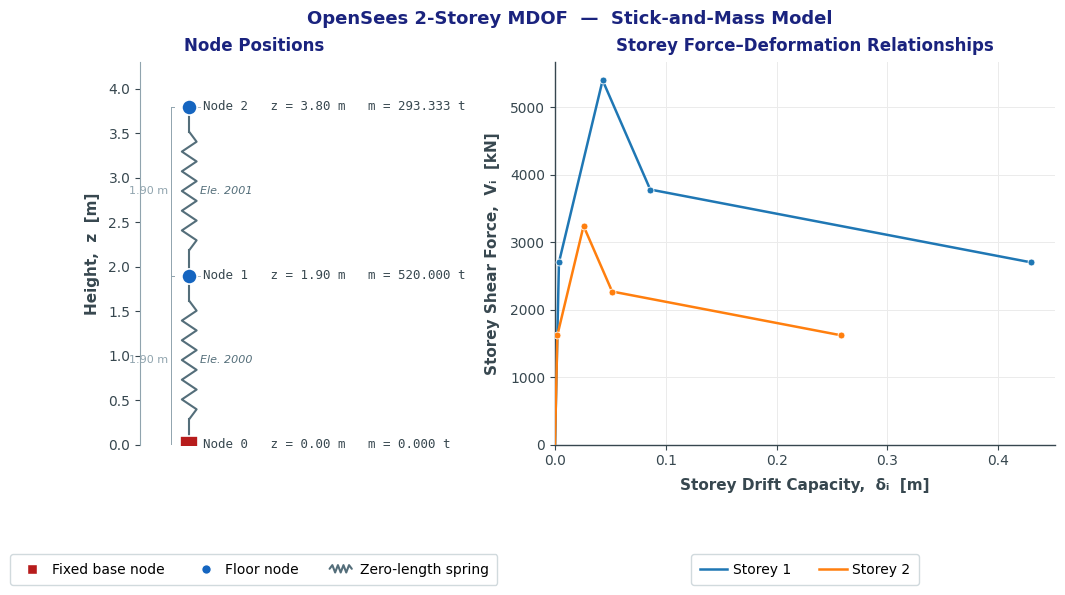

~~~~~~~ ANALYSIS SUCCESSFUL! ~~~~~~~~~
Saving SPO animation (41 frames) to: out/spo_animation.gif
ANALYSIS COMPLETED! (conv_index=0)


In [71]:
# Compile the MDOF model
model = modeller(number_of_stories,
                 floor_heights,
                 floor_masses,
                 story_drifts,
                 story_forces,
                 # No need to multiply by g since the units are already in kN
                 mdof_degradation)         # Initialise the class (Build the model)
model.compile_model()                      # Compile the MDOF model

# View the model
model.plot_model()                         # Visualise the model

# Do gravity analysis
model.do_gravity_analysis()                # Do gravity analysis

# Do modal analysis
T, phi = model.do_modal_analysis(num_modes=number_of_stories,
                                 plot_modes=False)   # Do modal analysis and get period of vibration

# Define pushover analysis parameters
ref_disp = 0.005                 # Reference displacement
disp_scale_factor = 30           # Multiplier of the reference displacement
push_dir = 1                     # Push direction (for X-direction:1, for Y-direction=2)
# Load pattern (In this example, we apply a user-defined triangular pattern)
phi = np.linspace(1/number_of_stories, 1.0, num=number_of_stories)

# Do pushover analysis
results = model.do_spo_analysis(
    ref_disp,
    disp_scale_factor,
    push_dir,
    phi,
    pFlag=False,
    num_steps=200,
    ansys_soe='BandGeneral',
    constraints_handler='Transformation',
    numberer='RCM',
    test_type='EnergyIncr',
    init_tol=1.0e-5,
    init_iter=1000,
    algorithm_type='KrylovNewton',
    # Export animation of SPO when setting path, set to None if you opt not to
    save_animation_path='out/spo_animation.gif')

print(f'ANALYSIS COMPLETED! (conv_index={results["conv_index"]})')

![spo_animation](out/spo_animation.gif)

### Cyclic pushover

In [73]:
# Compile the MDOF model
model = modeller(number_of_stories,
                 floor_heights,
                 floor_masses,
                 story_drifts,
                 story_forces,
                 mdof_degradation)         # Initialise the class (Build the model)
model.compile_model()                      # Compile the MDOF model

# View the model
# model.plot_model()                         # Visualise the model

# Do gravity analysis
model.do_gravity_analysis()                # Do gravity analysis

# Do modal analysis
T, phi = model.do_modal_analysis(num_modes=number_of_stories,
                                 plot_modes=False)   # Do modal analysis and get period of vibration

# Define pushover analysis parameters
ref_disp = 0.012                           # Reference (yield) displacement [m]

# Two-cycle protocol at each amplitude level (ATC-24 / FEMA 461 style):
# each ductility multiplier is repeated twice to produce two full positive-negative loops
mu_levels = [0.25, 0.25,
             0.50, 0.50,
             0.75, 0.75,
             1.00, 1.00,
             1.50, 1.50,
             2.00, 2.00,
             3.00, 3.00,
             4.00, 4.00,
             6.00, 6.00,
             8.00, 8.00,
             12.0, 12.0,
             16.0, 16.0]

# The number of displacement increments for each loading cycle
dispIncr = 10
max_step = ref_disp * 0.05                 # No step larger than 5% of yield displacement
# Load pattern (In this example, we apply a user-defined triangular pattern)
phi = np.linspace(1/number_of_stories, 1.0, num=number_of_stories)

# Do pushover analysis
results = model.do_cpo_analysis(
    ref_disp,
    mu_levels,
    push_dir,
    dispIncr,
    phi,
    max_step=max_step,
    pFlag=False,
    ansys_soe='BandGeneral',
    constraints_handler='Transformation',
    numberer='RCM',
    test_type='NormDispIncr',
    init_tol=1.0e-5,
    init_iter=1000,
    algorithm_type='KrylovNewton',
    # Export animation of CPO when setting path, set to None if you opt not to
    save_animation_path='out/cpo_animation.gif')

print('ANALYSIS COMPLETED!')

WARNING ZeroLength::setDomain(): Element 2000 has L= 1.9, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 1.9, which is greater than the tolerance



Saving animation to: out/cpo_animation.gif
ANALYSIS COMPLETED!


![cpo_animation](out/cpo_animation.gif)

In [76]:
4.1/0.49

8.36734693877551